In [2]:
import sys
!{sys.executable} -m pip install seaborn scikit-learn matplotlib pandas numpy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os, glob, ast, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [4]:
warnings.filterwarnings("ignore")
%matplotlib inline


In [5]:
DATA_PATH       = "C:/Users/risoe/OneDrive/Documents/telco_churn.csv"
PRED_DIR        = "C:/ChurnProject/ChurnPredictionSystem/output/predictions/"
STREAM_PRED_DIR = "C:/ChurnProject/ChurnPredictionSystem/output/streaming_results/"
PLOTS_DIR       = "C:/ChurnProject/ChurnPredictionSystem/output/plots/"
os.makedirs(PLOTS_DIR, exist_ok=True)

Dataset shape: (7043, 21)
  [SAVED] C:/ChurnProject/ChurnPredictionSystem/output/plots/1a_churn_distribution.png


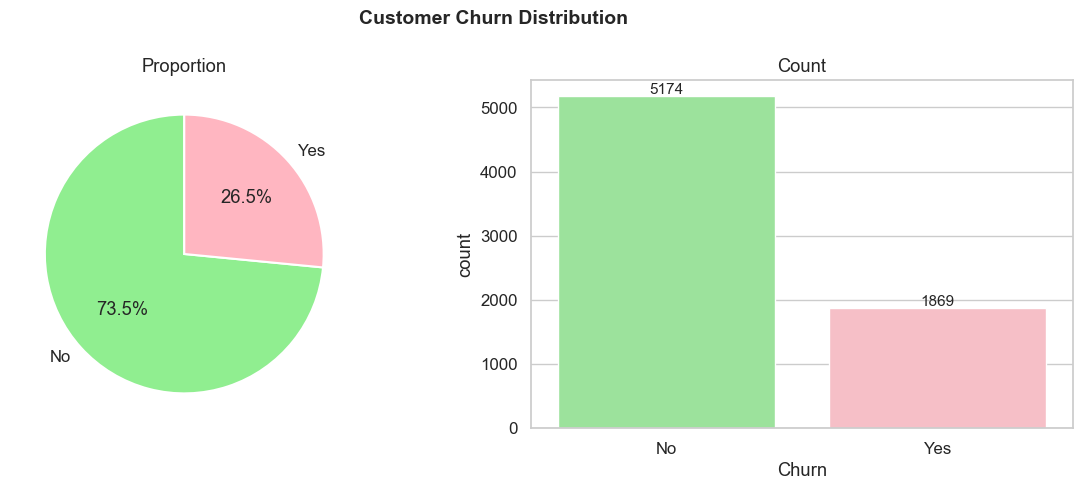

In [9]:
PALETTE = {"No": "#90EE90", "Yes": "#FFB6C1"}
sns.set_theme(style="whitegrid", font_scale=1.1)

def save_fig(fig, filename):
    path = os.path.join(PLOTS_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  [SAVED] {path}")

df = pd.read_csv(DATA_PATH)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
print(f"Dataset shape: {df.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Customer Churn Distribution", fontsize=14, fontweight="bold")
counts = df["Churn"].value_counts()
axes[0].pie(counts, labels=counts.index, autopct="%1.1f%%",
    colors=[PALETTE["No"], PALETTE["Yes"]],
    startangle=90, wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[0].set_title("Proportion")
sns.countplot(data=df, x="Churn", palette=PALETTE, ax=axes[1])
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=11)
axes[1].set_title("Count")
plt.tight_layout()
save_fig(fig, "1a_churn_distribution.png")
plt.show()

  [SAVED] C:/ChurnProject/ChurnPredictionSystem/output/plots/1b_numeric_distributions.png


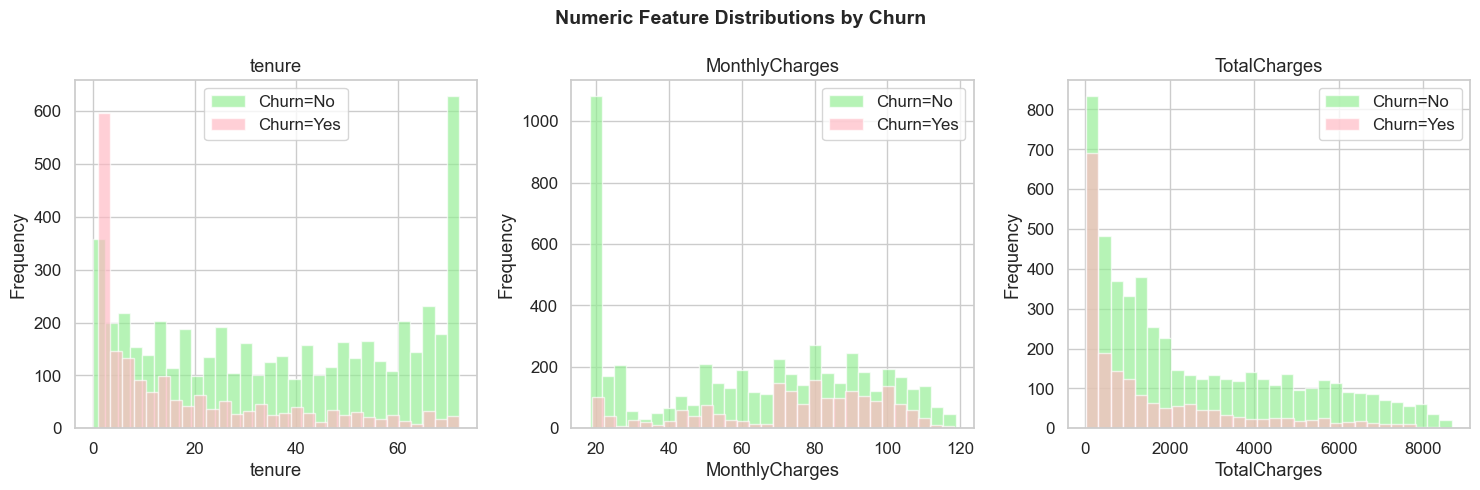

In [10]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Numeric Feature Distributions by Churn", fontsize=14, fontweight="bold")
for ax, col in zip(axes, num_cols):
    for val, color in PALETTE.items():
        data = df[df["Churn"] == val][col]
        ax.hist(data, bins=30, alpha=0.65, color=color, label=f"Churn={val}")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend()
plt.tight_layout()
save_fig(fig, "1b_numeric_distributions.png")
plt.show()

In [13]:
stream_files = glob.glob(os.path.join(STREAM_PRED_DIR, "*.csv"))

if not stream_files:
    print("[SKIP] No streaming results found. Run Phase2 + Simulator first.")
else:
    sdf = pd.concat([pd.read_csv(f) for f in stream_files], ignore_index=True)
    sdf["processed_at"] = pd.to_datetime(sdf["processed_at"])

    # Filter high risk customers
    high_risk = sdf[sdf["risk_tier"] == "HIGH RISK"].copy()
    high_risk = high_risk.sort_values("churn_probability", ascending=False)
    high_risk = high_risk.reset_index(drop=True)
    high_risk.index += 1

    print(f"Total customers processed : {len(sdf)}")
    print(f"High risk customers found : {len(high_risk)}")
    print(f"High risk percentage      : {len(high_risk)/len(sdf)*100:.1f}%")
    print()

    # Display top 20 high risk customers
    display_cols = ["customerID", "tenure", "Contract",
                    "MonthlyCharges", "InternetService",
                    "churn_probability", "churn_prediction", "risk_tier"]

    top20 = high_risk[display_cols].head(20)

    # Style the table
    styled = top20.style\
        .set_caption("Top 7 High Risk Customers — Sorted by Churn Probability")\
        .background_gradient(subset=["churn_probability"], cmap="Reds")\
        .set_properties(**{
            "font-size": "12px",
            "border": "1px solid #ddd",
            "text-align": "center"
        })\
        .set_table_styles([
            {"selector": "caption",
             "props": [("font-size", "14px"),
                       ("font-weight", "bold"),
                       ("padding", "10px"),
                       ("color", "#333")]},
            {"selector": "th",
             "props": [("background-color", "#FFB6C1"),
                       ("color", "#333"),
                       ("font-size", "12px"),
                       ("padding", "8px"),
                       ("text-align", "center")]},
            {"selector": "tr:hover",
             "props": [("background-color", "#fff0f0")]}
        ])\
        .format({"churn_probability": "{:.4f}",
                 "MonthlyCharges": "${:.2f}"})

    display(styled)

    # Save to CSV
    output_path = "C:/ChurnProject/ChurnPredictionSystem/output/high_risk_customers.csv"
    high_risk.to_csv(output_path, index=False)
    print(f"\n[SAVED] High risk customers saved to: {output_path}")

Total customers processed : 72
High risk customers found : 7
High risk percentage      : 9.7%



,customerID,tenure,Contract,MonthlyCharges,InternetService,churn_probability,churn_prediction,risk_tier
1,8779-QRDMV,1,Month-to-month,$70.65,Fiber optic,0.8972,WILL CHURN,HIGH RISK
2,0063-IRCLG,1,Month-to-month,$69.90,Fiber optic,0.8926,WILL CHURN,HIGH RISK
3,0071-SMEOE,12,Month-to-month,$94.65,Fiber optic,0.8743,WILL CHURN,HIGH RISK
4,9237-HQITU,2,Month-to-month,$70.70,Fiber optic,0.8609,WILL CHURN,HIGH RISK
5,9237-HQITU,2,Month-to-month,$70.70,Fiber optic,0.8609,WILL CHURN,HIGH RISK
6,0056-EPFBG,2,Month-to-month,$75.90,Fiber optic,0.8431,WILL CHURN,HIGH RISK
7,0030-DNFRF,1,Month-to-month,$24.75,No,0.7539,WILL CHURN,HIGH RISK



[SAVED] High risk customers saved to: C:/ChurnProject/ChurnPredictionSystem/output/high_risk_customers.csv
